# Figure2(Stackedbar) for bertopic

In [1]:
bertopic_idx = input("INPUT 'visualization_target for BERTopic RUN_ID'(e.g., 200): ")

print(f'Figure will be drawn based on the run_id_{bertopic_idx} dataset')

Figure will be drawn based on the run_id_200 dataset


In [2]:
tag_idx = input("INPUT 'visualization_target for Tag RUN_ID'(e.g., 100): ")
print(f'Figure will be drawn based on the run_id_{tag_idx} dataset')

Figure will be drawn based on the run_id_100 dataset


In [3]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
from lib.topic_modeling.result_prep import Result_Prep as Result_Prep_Topic
from lib.tag_analysis.result_prep import Result_Prep as Result_Prep_Tag
import lib.visualization.figure_setting as figure_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      get_distribution_by_list,
                                                      calc_top_bottom_tags_prop)
mpl.rcParams.update(figure_setting.fig_setting)


In [4]:
rp_topic = Result_Prep_Topic(bertopic_idx, model_in_run='bert_based')
topic_df = rp_topic.data_prep()
prop_df = proportion_calc_for_topic(topic_df, 'rel_week', 'Topic')
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
            'Bottom 20% Topics' : bot10list, 
            'Mid 60% Topics': mid30list}


topic_proportion_dict = {     'Top 20% Topics'        : get_distribution_by_list(prop_df, top10list),   
                              'Bottom 20% Topics'     : get_distribution_by_list(prop_df, bot10list),}

In [5]:
rp_tag = Result_Prep_Tag(tag_idx, model_in_run='tag')
tag_df = rp_tag.data_prep()
tag_proportion_dict = calc_top_bottom_tags_prop(tag_df)

In [6]:
def draw_bar_plot_for_bertopic(ax, i, title, proportion, list_10):
    # color_list = Color_Setting.color_list


    color_list = [[figure_setting.PALETTE['neutral']] *10, [figure_setting.PALETTE['neutral']] *10]

    alpha_list = [0.25, 0.25, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    plotgen = PlotGen()
    ### stacked topic plots
    x = proportion['rel_week'].values
    y = proportion['proportion'].values
    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    _ , p_value = st_chow.chow_test()

    plotgen.draw_tag_bar( ax
                        , title 
                        , x
                        , y
                        , color_list[i]
                        , alpha_list[i]
                        , ''
                        , set_ylim = False
                        , p_value = p_value)

    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]
    
    # ── Overall fit 
    # plotgen.draw_line_plot(ax, x, st_chow.y_predict, label='Overall fit', color=figure_setting.PALETTE['neutral'])

    # ── Before ChatGPT
    plotgen.fill_confidence_interval(ax, x1, st_chow.y1_predict - st_chow.y1_conf_interval, st_chow.y1_predict + st_chow.y1_conf_interval
                                          , label=None, color = figure_setting.PALETTE['primary'])
    plotgen.draw_line_plot(ax, x1, st_chow.y1_predict, 
                           label='Before ChatGPT', 
                           color=figure_setting.PALETTE['primary'])

    # ── After ChatGPT
    plotgen.fill_confidence_interval(ax, x2, st_chow.y2_predict - st_chow.y2_conf_interval, st_chow.y2_predict + st_chow.y2_conf_interval
                                          , label=None, color = figure_setting.PALETTE['accent'])
    plotgen.draw_line_plot(ax, x2, st_chow.y2_predict,
            label='After ChatGPT',
            color=figure_setting.PALETTE['accent'])
    

In [7]:
def draw_bar_plot_for_tag(ax, i, title, proportion):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    alpha_list = [0.25, 0.25]
    color_list = [[figure_setting.PALETTE['neutral']] *10, [figure_setting.PALETTE['neutral']] *10]
    plotgen = PlotGen()

    x = proportion['rel_week'].values
    y = proportion['pct_pct'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    _ , p_value = st_chow.chow_test()
    # full_title = plotgen.get_title(prefix = None, title_text = title, p_value = p_value)
    
    plotgen.draw_tag_bar( ax
                        , title 
                        , x
                        , y
                        , color_list[i]
                        , alpha_list[i]
                        , ''
                        , set_ylim = False
                        , p_value = p_value)
    
    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]
    
    # ── Overall fit 
    # plotgen.draw_line_plot(ax, x, st_chow.y_predict, label='Overall fit', color=figure_setting.PALETTE['neutral'])

    # ── Before ChatGPT
    plotgen.fill_confidence_interval(ax, x1, st_chow.y1_predict - st_chow.y1_conf_interval, st_chow.y1_predict + st_chow.y1_conf_interval
                                          , label=None, color = figure_setting.PALETTE['primary'])
    plotgen.draw_line_plot(ax, x1, st_chow.y1_predict, label='Before ChatGPT', color=figure_setting.PALETTE['primary'])

    # ── After ChatGPT
    plotgen.fill_confidence_interval(ax, x2, st_chow.y2_predict - st_chow.y2_conf_interval, st_chow.y2_predict + st_chow.y2_conf_interval
                                          , label=None, color = figure_setting.PALETTE['accent'])
    plotgen.draw_line_plot(ax, x2, st_chow.y2_predict,
            label='After ChatGPT',
            color=figure_setting.PALETTE['accent'])
    

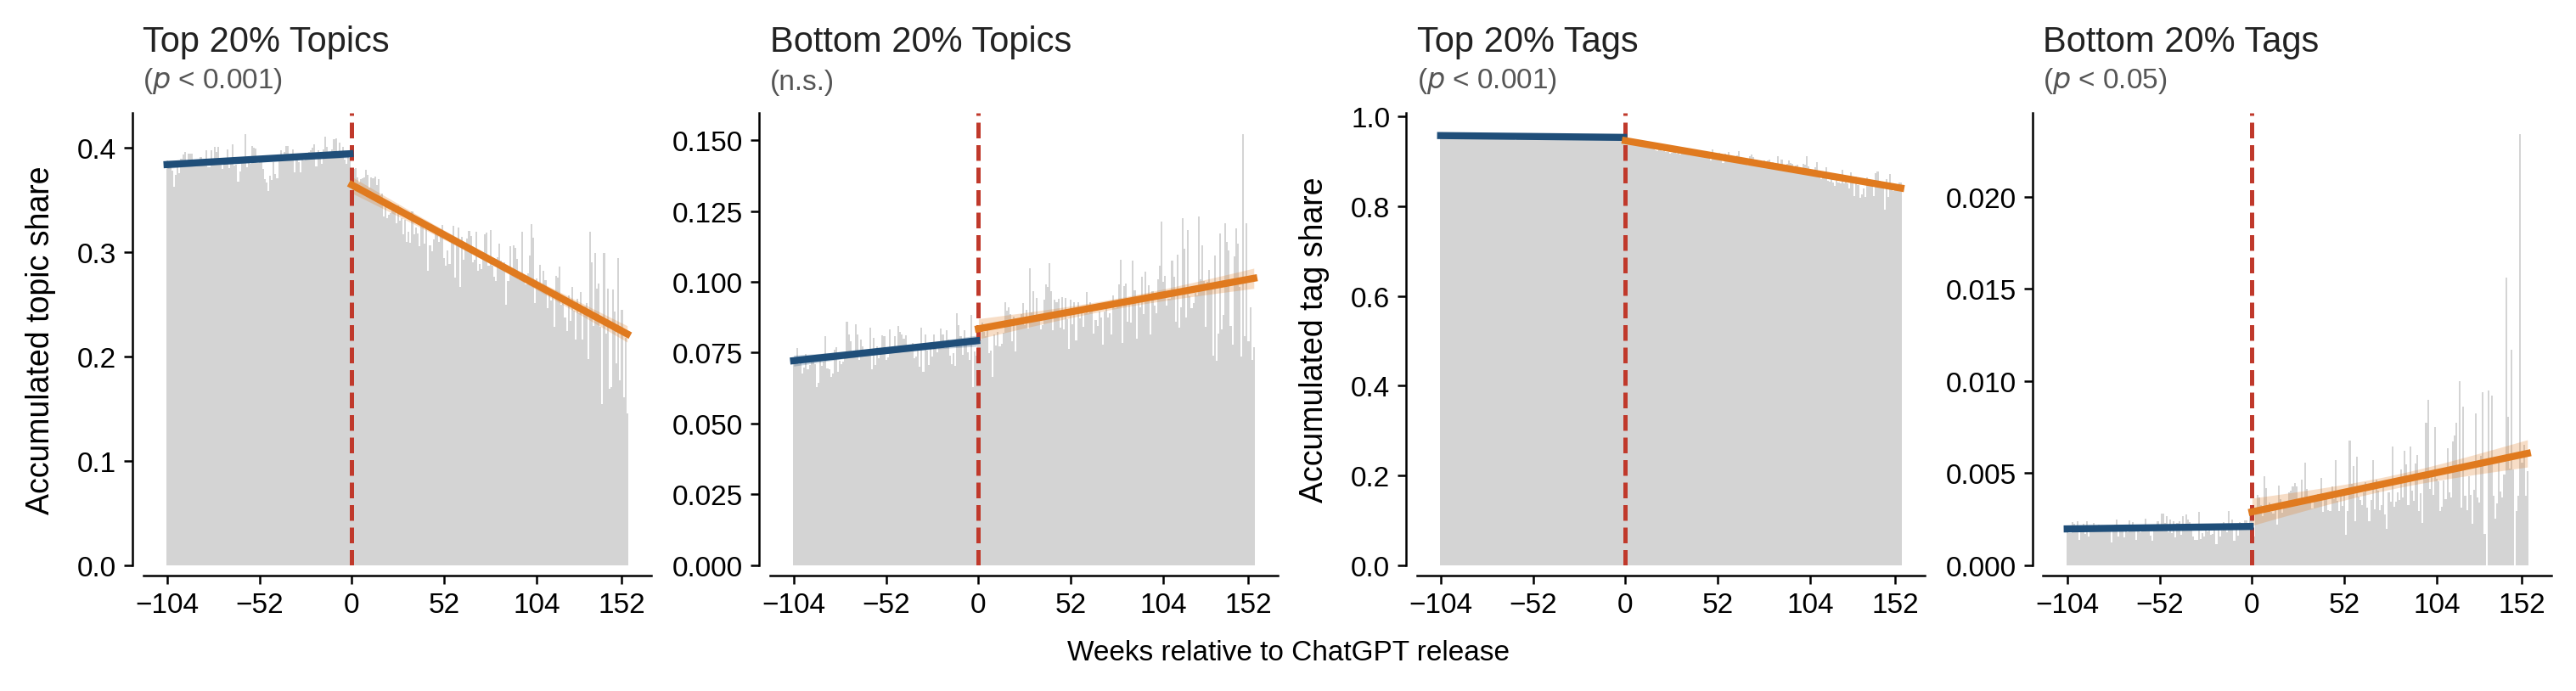

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(10, 2.6), constrained_layout=True,  dpi=300)


base_idx = 0
for i, (title, proportion) in enumerate(topic_proportion_dict.items()):
    draw_bar_plot_for_bertopic(
        ax[base_idx+i],
        i,
        title,
        proportion,
        list_10[title]
    )

base_idx = 2
for i, (title, proportion) in enumerate(tag_proportion_dict.items()):
    draw_bar_plot_for_tag( ax[base_idx+i]
                        , i
                        , f'{title}' 
                        , proportion
    )

ax[0].set_ylabel("Accumulated topic share", labelpad=6)
ax[-2].set_ylabel("Accumulated tag share", labelpad=6)
fig.supxlabel("Weeks relative to ChatGPT release", fontsize=figure_setting.FONT['label'])
plt.savefig('./fig/Fig2.pdf', bbox_inches='tight', dpi=300)



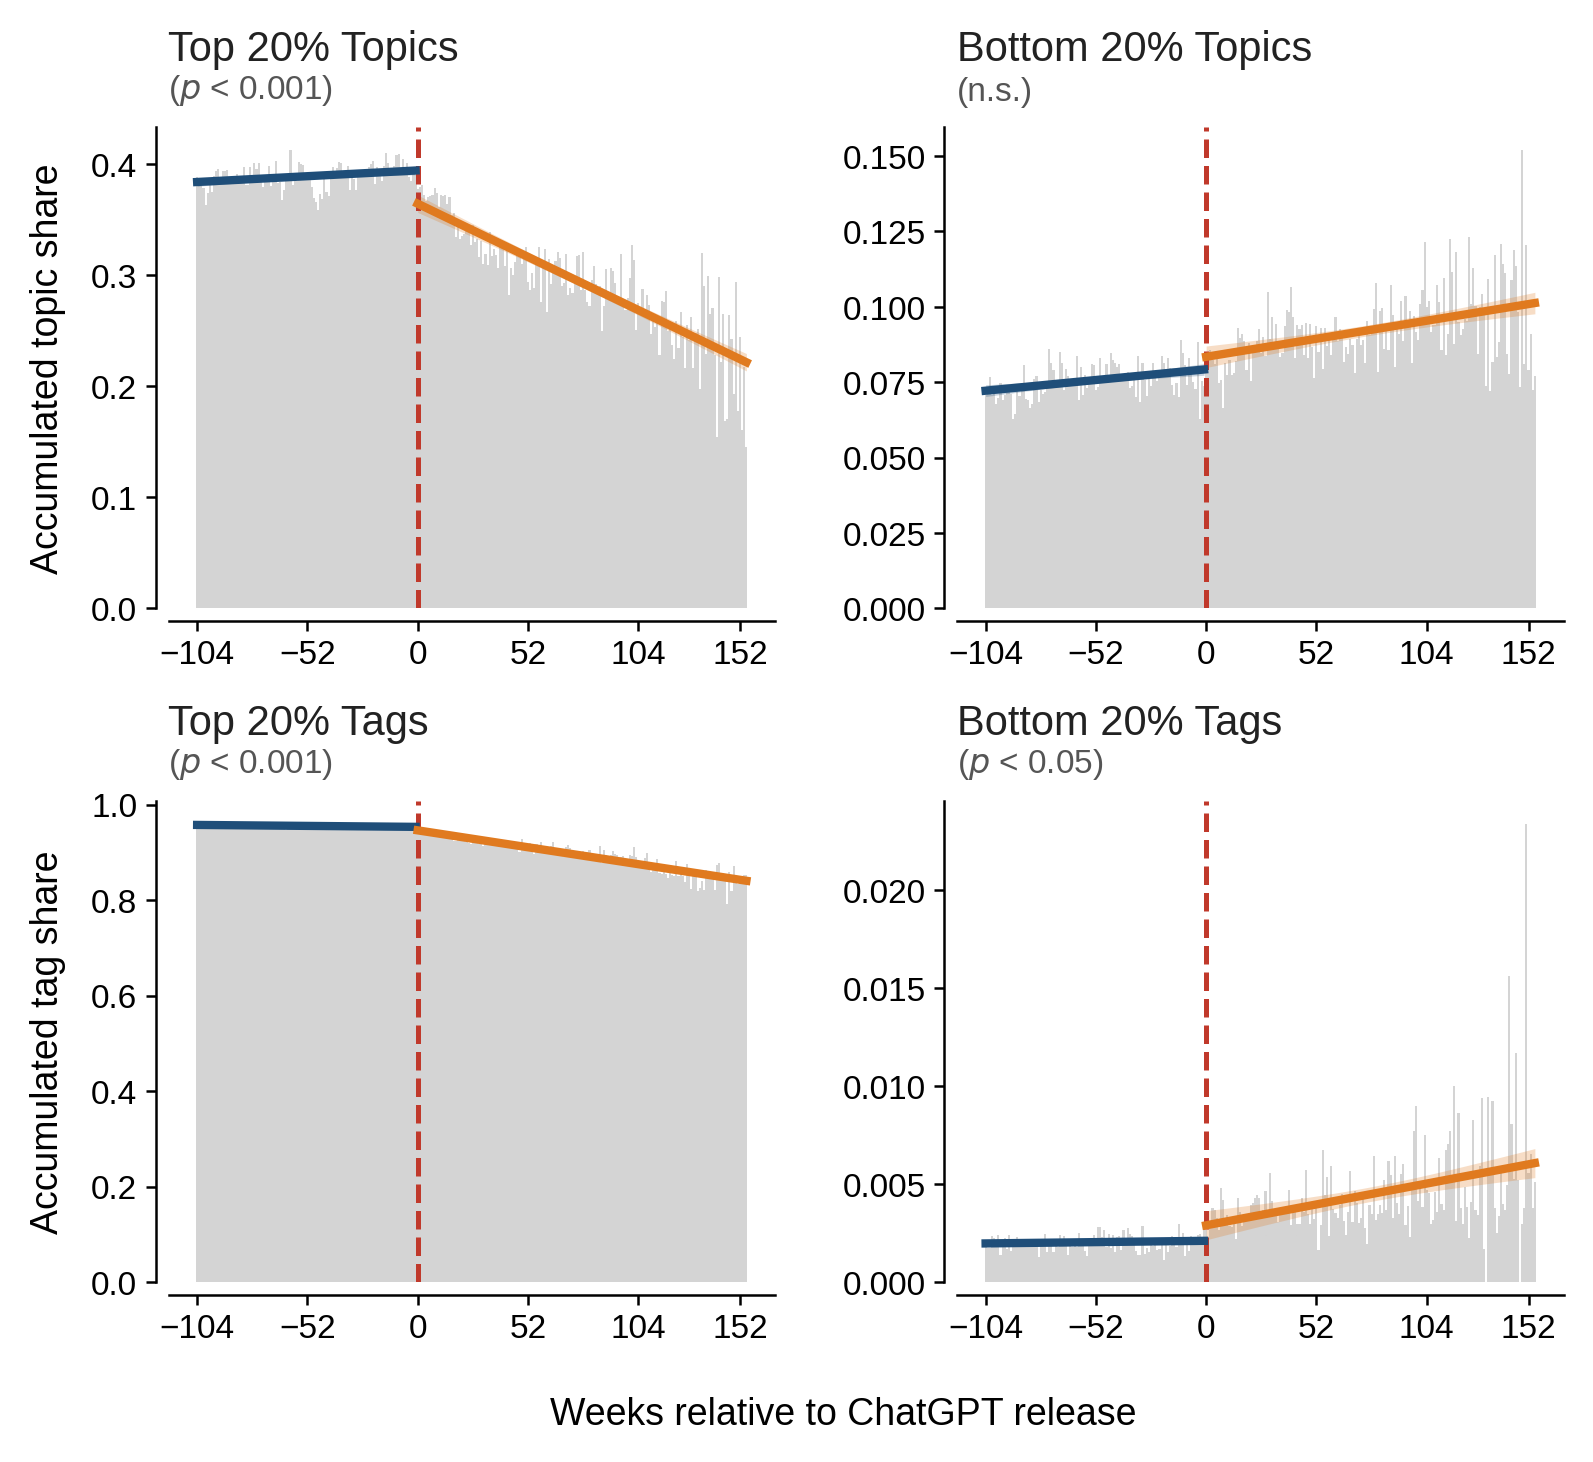

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(6, 5), dpi=300)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # Top Topics
ax2 = fig.add_subplot(gs[0, 1])   # Bottom Topics
ax3 = fig.add_subplot(gs[1, 0])   # Top Tags
ax4 = fig.add_subplot(gs[1, 1])   # Bottom Tags

axes = [ax1, ax2, ax3, ax4]

base_idx = 0
for i, (title, proportion) in enumerate(topic_proportion_dict.items()):
    draw_bar_plot_for_bertopic(
        axes[base_idx+i],
        i,
        title,
        proportion,
        list_10[title]
    )

base_idx = 2
for i, (title, proportion) in enumerate(tag_proportion_dict.items()):
    draw_bar_plot_for_tag( axes[base_idx+i]
                        , i
                        , f'{title}' 
                        , proportion
    )


ax1.set_ylabel("Accumulated topic share", labelpad=6)
ax3.set_ylabel("Accumulated tag share", labelpad=6)
fig.supxlabel("Weeks relative to Gen AI release", fontsize = figure_setting.fig_setting['axes.labelsize'])

plt.savefig('./fig/Fig2.pdf', bbox_inches='tight', dpi=300)



In [10]:
proportion = topic_proportion_dict['Bottom 20% Topics']

In [11]:
return_df = proportion[proportion['Topic'].isin(sort_list)].copy() 

KeyError: 'Topic'

In [ ]:
p_value

In [ ]:
proportion.tail(50)

In [ ]:
"""
ITS (Interrupted Time Series) 분석
----------------------------------
개입(intervention) 전후로 시계열의 '레벨(level)'과 '기울기(slope)'가
유의하게 변했는지 검정합니다.

모형:
    y_t = b0 + b1*time_t + b2*post_t + b3*(time_t * post_t) + e_t

    - time      : 전체 기간에 대해 0,1,2,... 로 이어지는 시간 인덱스 (개입 시점과 무관하게 연속)
    - post      : 개입 이후면 1, 이전이면 0 (더미변수)
    - time_since_post : 개입 시점부터 다시 0,1,2,...로 카운트한 시간 * post
                        (개입 전 기간은 0으로 둠. time_idx를 그대로 곱하면 b2가
                         time=0 시점으로 외삽되어 레벨 변화 해석이 왜곡되므로 반드시 이렇게 처리)

계수 해석:
    b0 : 개입 전 시작 시점의 레벨(절편)
    b1 : 개입 전 기울기(추세)
    b2 : 개입 시점에서의 레벨 변화(즉각적 효과, level shift)
    b3 : 개입 후 기울기 변화(추세 변화) → "기울기 차이"를 보고 싶다면 이 계수의 유의성을 확인

표준오차:
    시계열 데이터는 자기상관(autocorrelation)이 있는 경우가 많아서
    기본 OLS 표준오차 대신 Newey-West(HAC) robust 표준오차를 기본으로 사용합니다.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm


def its_test(df, time_col, y_col, intervention_time, maxlags=None):
    """
    Interrupted Time Series 분석 수행

    Parameters
    ----------
    df : pd.DataFrame
        시계열 데이터. 시간 순으로 정렬되어 있어야 함
    time_col : str
        시간(또는 날짜/인덱스) 컬럼명
    y_col : str
        종속변수 컬럼명
    intervention_time : same type as df[time_col]
        개입이 시작된 시점 (이 시점부터 post=1)
    maxlags : int, optional
        Newey-West HAC 표준오차 계산 시 사용할 최대 시차.
        None이면 관측치 수 기반 경험적 규칙(0.75 * n^(1/3))으로 자동 설정

    Returns
    -------
    model : statsmodels RegressionResultsWrapper
        robust SE가 적용된 회귀 결과 (model.summary()로 전체 확인 가능)
    result_df : pd.DataFrame
        계수, robust SE, t값, p값을 정리한 요약표
    """
    data = df.copy().sort_values(time_col).reset_index(drop=True)

    # 1) 연속적인 시간 인덱스 생성 (0, 1, 2, ...)
    n = len(data)
    data["_time_idx"] = np.arange(n)

    # 2) 개입 여부(post) 더미 생성
    data["_post"] = (data[time_col] >= intervention_time).astype(int)

    # 3) 상호작용항: '개입 시점부터' 다시 0부터 카운트한 시간 * post
    #    (time_idx 전체값을 그대로 곱하면 post 계수가 time=0 시점으로 외삽되어
    #     레벨 변화 해석이 왜곡되므로, 반드시 개입 시점 기준으로 센터링한다)
    intervention_idx = data.loc[data["_post"] == 1, "_time_idx"].min()
    data["_time_since"] = np.where(
        data["_post"] == 1, data["_time_idx"] - intervention_idx, 0
    )
    data["_time_post"] = data["_time_since"] * data["_post"]

    X = data[["_time_idx", "_post", "_time_post"]]
    X = sm.add_constant(X)
    y = data[y_col]

    ols_model = sm.OLS(y, X).fit()

    # 4) Newey-West(HAC) robust 표준오차 적용
    if maxlags is None:
        maxlags = int(np.floor(0.75 * n ** (1 / 3)))

    robust_model = ols_model.get_robustcov_results(cov_type="HAC", maxlags=maxlags)

    coef_names = ["const (b0: 초기 레벨)", "time (b1: 개입 전 기울기)",
                  "post (b2: 레벨 변화)", "time*post (b3: 기울기 변화)"]

    result_df = pd.DataFrame({
        "coef": robust_model.params,
        "robust_se": robust_model.bse,
        "t": robust_model.tvalues,
        "p_value": robust_model.pvalues,
    }, index=coef_names)

    return robust_model, result_df


def print_its_summary(result_df, alpha=0.05):
    print("=== ITS 분석 결과 (Newey-West robust SE) ===\n")
    print(result_df.round(5))
    print()

    slope_row = result_df.loc["time*post (b3: 기울기 변화)"]
    level_row = result_df.loc["post (b2: 레벨 변화)"]

    print(f"[레벨 변화, b2] coef={level_row['coef']:.5f}, p={level_row['p_value']:.4f} "
          f"→ {'유의함' if level_row['p_value'] < alpha else '유의하지 않음'}")
    print(f"[기울기 변화, b3] coef={slope_row['coef']:.5f}, p={slope_row['p_value']:.4f} "
          f"→ {'유의함' if slope_row['p_value'] < alpha else '유의하지 않음'}")


if __name__ == "__main__":
    # ------------------------------------------------------------
    # 사용 예시: 임의 데이터 (개입 후 기울기만 변하는 상황)
    # ------------------------------------------------------------
    np.random.seed(42)
    n = 200
    time_idx = np.arange(n)
    intervention_at = 100  # 100번째 시점부터 개입

    # 개입 전: y = 2 + 0.05*t + noise
    # 개입 후: y = 2 + 0.05*t + 0.15*(t-100) + noise  (기울기만 커짐, 레벨 점프는 없음)
    y = 2 + 0.05 * time_idx + np.random.normal(0, 0.5, n)
    post_mask = time_idx >= intervention_at
    y[post_mask] += 0.15 * (time_idx[post_mask] - intervention_at)

    df_example = pd.DataFrame({"time": time_idx, "y": y})

    model, result_df = its_test(
        df_example,
        time_col="time",
        y_col="y",
        intervention_time=intervention_at
    )

    print_its_summary(result_df)

    print("\n--- 전체 statsmodels summary ---")
    print(model.summary())

    # ------------------------------------------------------------
    # 실제 사용 시 예시
    # ------------------------------------------------------------
    # df = pd.read_csv("your_data.csv", parse_dates=["date"])
    # model, result_df = its_test(df, time_col="date", y_col="y",
    #                              intervention_time=pd.Timestamp("2020-01-01"))
    # print_its_summary(result_df)

In [ ]:
x = proportion['rel_week'].values
y = proportion['proportion'].values
idx = np.where(x < 0)[0][-1] + 1

In [ ]:
x[:idx]

In [ ]:
proportion

In [ ]:
result = chow_test(x[:idx], y[:idx], x[idx:], y[idx:])

In [ ]:
result

In [ ]:
tag_df